In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

### ---------------------------------------------------------
### Step 1: 데이터 로드 및 결합 (Master DOE + 개별 CSV)
### ---------------------------------------------------------

In [2]:
# 1-1. 마스터 DOE 파일 로드
master_df = pd.read_csv('D:\AI_Study\GitHub\Battery\Master_DOE_1200.csv')

In [3]:
# 1-2. 데이터셋 CSV 파일들에서 'Max Peak' 추출하여 합치기
path = './Battery/데이터셋/'
combined_list = []

In [4]:
# 마스터 파일의 인덱스를 순회하며 해당 번호의 상세 파일을 찾아 Max Peak 추출
# 파일명이 'ML_DATA_Extract_Row_0.csv' 형태라고 가정
for i, row in master_df.iterrows():
    file_path = os.path.join(path, f'ML_DATA_Extract_Row_{i}.csv')
    
    if os.path.exists(file_path):
        temp_data = pd.read_csv(file_path)
        
        # 상세 데이터에서 Max Peak(Y값) 추출 (절댓값 최대치)
        # 컬럼명은 실제 CSV의 헤더인 'Max_Peak' 또는 'Value' 등에 맞춰주세요.
        # 여기서는 상세 데이터 내에 'Peak'라는 컬럼이 있다고 가정하고 최대값을 뽑습니다.
        max_peak_value = temp_data.iloc[:, -1].abs().max() # 마지막 컬럼의 절댓값 중 최대값
        
        # 마스터의 P1~P6 조건에 추출한 Max Peak 값을 붙여서 저장
        combined_row = row.to_dict()
        combined_row['Max_Peak_Target'] = max_peak_value
        combined_list.append(combined_row)

In [5]:
# 최종 학습용 데이터프레임 생성
df_final = pd.DataFrame(combined_list)
print(f"학습용 데이터 구성 완료: {len(df_final)} 행")

학습용 데이터 구성 완료: 361 행


In [6]:
# ---------------------------------------------------------
# Step 0: 데이터 병합 (수많은 CSV 하나로 합치기)
# ---------------------------------------------------------
# path = '.\Battery\데이터셋' 
# file_list = glob.glob(os.path.join(path, "*.csv"))
# # file_list

# if not file_list:
#     print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")
# else:
#     # 모든 CSV를 읽어 리스트에 담고 한 번에 합침
#     datas = [pd.read_csv(f) for f in file_list]
#     df_combined = pd.concat(datas, ignore_index=True)
#     print(f"총 {len(file_list)}개의 파일을 합쳐 {len(df_combined)}행의 데이터를 로드했습니다.")

### ---------------------------------------------------------
### Step 2: EDA (탐색적 데이터 분석)
### ---------------------------------------------------------

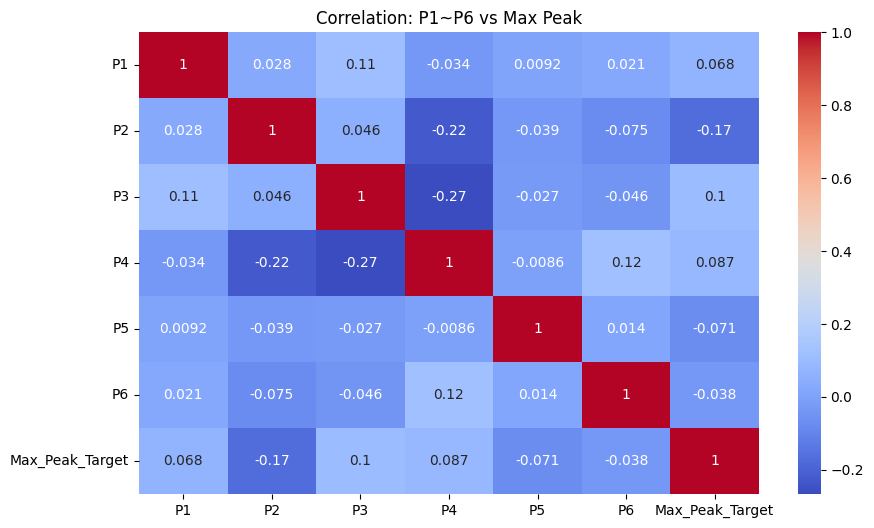

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation: P1~P6 vs Max Peak")
plt.show()

In [8]:
# # 데이터 구조 확인 (P1~P6이 입력, 특정 컬럼이 Max Peak라고 가정)
# print(df_combined.info())
# print(df_combined.describe())

In [9]:
# # 상관관계 히트맵 (어떤 인자가 Max Peak에 큰 영향을 주는지 확인)
# plt.figure(figsize=(10, 8))
# sns.heatmap(df_combined.corr(), annot=True, cmap='coolwarm', fmt='.2f')
# plt.title("Feature Correlation")
# plt.show()

### ---------------------------------------------------------
### Step 3: 대리 모델(Surrogate) 학습 - XGBoost
### ---------------------------------------------------------

In [10]:
# Master_DOE_1200.csv의 컬럼명인 P1, P2, P3, P4, P5, P6를 사용
features = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
X = df_final[features]
y = df_final['Max_Peak_Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [11]:
# 검증
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

R2 Score: -0.2520


In [12]:
# # 데이터셋 컬럼명에 맞춰 수정 필요 (예: P1~P6, Max_Peak)
# # 여기서는 입력변수를 'P1','P2','P3','P4','P5','P6'로 가정합니다.
# features = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
# target = 'Max_Peak' # 실제 데이터셋의 결과값 컬럼명으로 수정하세요.

# X = df_combined[features]
# y = df_combined[target]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # XGBoost 회귀 모델 설정
# model = xgb.XGBRegressor(
#     n_estimators=1000,
#     learning_rate=0.01,
#     max_depth=7,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )

# print("\n대리 모델 학습 중...")
# model.fit(X_train, y_train)

### ---------------------------------------------------------
### Step 4: Monte Carlo를 이용한 10만 개 가상 데이터 생성
### ---------------------------------------------------------

In [13]:
print("\n10만 개의 가상 조합 생성 중...")
n_virtual = 100000


10만 개의 가상 조합 생성 중...


In [14]:
# P1~P6의 실제 범위를 기반으로 난수 생성
virtual_input = pd.DataFrame()
for col in features:
    virtual_input[col] = np.random.uniform(X[col].min(), X[col].max(), n_virtual)

In [15]:
# 대리 모델을 통한 결과 예측 (Data Augmentation)
virtual_input['Predicted_Max_Peak'] = model.predict(virtual_input)

print("가상 데이터 생성 완료!")
print(virtual_input.head())

가상 데이터 생성 완료!
         P1        P2        P3        P4        P5        P6  \
0  0.889267  0.060921  0.710858  0.140162  1.450766  0.059064   
1  0.936858  0.086991  0.669703  0.173095  1.227793  0.051360   
2  1.075456  0.087268  0.692875  0.251082  1.222206  0.040381   
3  0.883527  0.079324  0.672562  0.211598  1.789624  0.043105   
4  0.993434  0.050791  0.715242  0.172132  1.646557  0.063252   

   Predicted_Max_Peak  
0           91.886101  
1           89.408508  
2           87.856400  
3           86.915512  
4           85.767326  


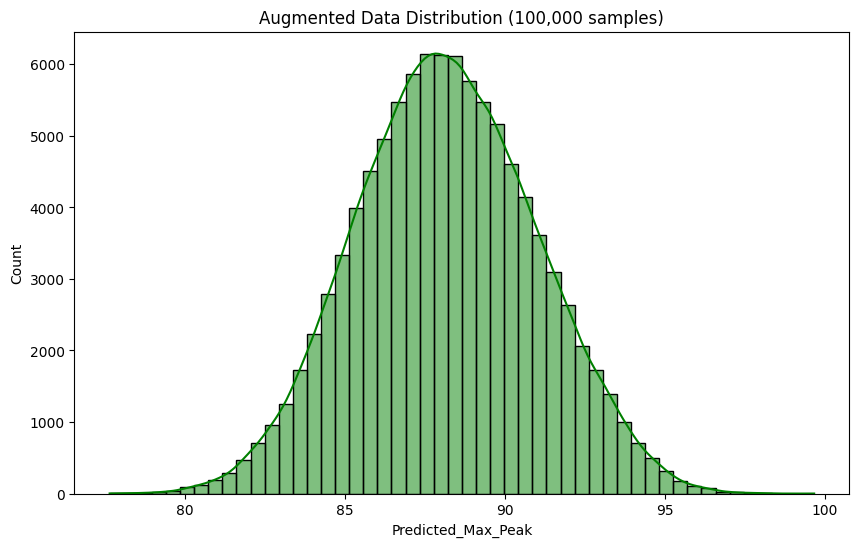

In [16]:
# 가상 데이터 분포 시각화
plt.figure(figsize=(10, 6))
sns.histplot(virtual_input['Predicted_Max_Peak'], bins=50, kde=True, color='green')
plt.title("Augmented Data Distribution (100,000 samples)")
plt.show()

코드 수정 포인트:
1. Master 파일 활용: Master_DOE_1200.csv를 먼저 읽어 $P_1 \sim P_6$ 조건을 확보합니다.

2. 데이터 매칭: 마스터 파일의 각 행 인덱스(i)를 이용해 ./Battery/데이터셋/ML_DATA_Extract_Row_{i}.csv 파일을 순서대로 찾아 읽습니다.

3. 지표 추출 (Max Peak): 상세 데이터 파일에서 abs().max()를 사용하여 깃허브 설명에 나온 '절댓값 Max Peak' 지표를 자동으로 추출하여 $Y$값으로 설정합니다.

4. 확장: 학습된 모델로 10만 개의 새로운 $P_1 \sim P_6$ 조합에 대한 예측값을 계산하여 데이터를 증강합니다.주의: 상세 CSV 파일 내에서 'Max Peak'를 계산할 컬럼의 인덱스나 이름이 정확한지 확인해 주세요. 위 코드에서는 temp_data.iloc[:, -1](마지막 컬럼)을 기준으로 작성되었습니다.

In [17]:
# 1. 상세 파일이 있는 경로 설정
sample_path = './Battery/데이터셋/'
sample_files = glob.glob(os.path.join(sample_path, "*.csv"))

if sample_files:
    # 첫 번째 파일 선택
    sample_file = sample_files[0]
    print(f"--- 상세 파일 분석: {os.path.basename(sample_file)} ---")
    
    # 데이터 불러오기
    df_sample = pd.read_csv(sample_file)
    
    # 2. 컬럼명 출력
    print(f"1. 전체 컬럼명: {df_sample.columns.tolist()}")
    
    # 3. 데이터 샘플 출력 (상단 3행)
    print("\n2. 데이터 미리보기:")
    print(df_sample.head(3))
    
    # 4. 수치 데이터 요약 (Max Peak 계산을 위해)
    print("\n3. 수치 데이터 요약 (통계량):")
    print(df_sample.describe())
else:
    print("파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")

--- 상세 파일 분석: ML_DATA_Extract_Row_0(비교용).csv ---
1. 전체 컬럼명: ['Time', ' TempBase', ' WarpMax', ' T_Tip_Peel', ' T_Tip_Shear', ' T_Tip_SEQV', ' T_Tip_Strain', ' T_Avg_Peel', ' T_Avg_Shear', ' B_Tip_Peel', ' B_Tip_Shear', ' B_Tip_SEQV', ' B_Tip_Strain', ' B_Avg_Peel', ' B_Avg_Shear', ' Die_SX', ' Die_SY_Max']

2. 데이터 미리보기:
   Time    TempBase   WarpMax   T_Tip_Peel   T_Tip_Shear   T_Tip_SEQV  \
0  0.10  119.783188 -0.117491   -33.906822     -4.554427    35.676788   
1  0.20  119.365982 -0.114489   -32.821039     -4.190090    34.399391   
2  0.35  116.013115 -0.107182   -29.215017     -3.082544    30.259626   

    T_Tip_Strain   T_Avg_Peel   T_Avg_Shear   B_Tip_Peel   B_Tip_Shear  \
0       0.002045     0.006655     -2.664144    -4.176999     -2.040079   
1       0.001985     0.006968     -2.571259    -4.121848     -1.983519   
2       0.001774     0.006249     -2.259908    -3.933210     -1.775690   

    B_Tip_SEQV   B_Tip_Strain   B_Avg_Peel   B_Avg_Shear     Die_SX  \
0    24.093281   